# HW2: Do Stocks Outperform Treasury Bills?

Replication and extensions of Bessembinder (2018), following [Plan.md](Plan.md). Part 1 covers Table 1 (simulated multi-period returns); Part 2 covers Table 4 with industries.

Run from the `HW2` folder. Each simulation is cached in `output/` as a CSV plus a JSON description of the run. A cache is reused only if that description matches the requested run exactly, including a fingerprint of the simulator source; otherwise the notebook stops, and `REFRESH = True` recomputes. The validation checks stop the notebook before any table is exported if a simulation fails them. Unit checks: `python -m unittest discover -s tests`.

In [1]:
import sys
from pathlib import Path
from statistics import NormalDist

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

sys.path.insert(0, str(Path("src").resolve()))
from sim_cache import run_cached
from table1_report import (compare_with_paper, enforce_checks, load_paper_table1, moment_checks, panel,
                           paper_panel, skewness_table, skewness_warnings, stacked_panel)
from table1_sim import exact_moments

OUTPUT = Path("output")
REFRESH = False  # True recomputes every simulation
PAPER = load_paper_table1()


def pct_columns(frame, digits=0):
    # Label volatility columns as percentages.
    return frame.rename(columns=lambda s: f"{s:.{digits}%}")


def show_panel(shown, title, fmt, scaled_rows=("diff / seed SD",)):
    # Percent-format a stacked panel, except rows measured in seed SDs.
    scaled = shown.index.get_level_values("row").isin(scaled_rows)
    style = (shown.style.set_caption(title).format_index("{:.0f}", axis=0, level=0)
             .format(fmt, subset=(shown.index[~scaled], slice(None)), na_rep=""))
    if scaled.any():
        style = style.format("{:.1f}", subset=(shown.index[scaled], slice(None)), na_rep="")
    display(style)


def show_checks(checks):
    # Summarize the mean/sd checks; enforce_checks raises first if any applicable row fails.
    summary = enforce_checks(checks)
    display(summary.style.format({"max_abs_mean_z": "{:.2f}", "max_abs_sd_z": "{:.2f}"}, na_rep=""))
    return summary


def show_skew(table, columns, sigma_format="{:.0%}"):
    formats = {"horizon_years": "{:.0f}", "sigma": sigma_format, "paper_sigma": "{:.0%}", "exact_skew": "{:.3f}",
               "paper": "{:.3f}", "ours": "{:.3f}", "skew_min": "{:.3f}", "skew_max": "{:.3f}", "skew_bound": "{:.0f}"}
    shown = table.query("sigma > 0")[columns]
    display(shown.style.hide(axis="index").format({k: v for k, v in formats.items() if k in columns}, na_rep="n/a"))

## Part 1: Table 1

### Step 2: Validate the simulator against the paper

The paper draws monthly simple returns from a normal distribution with mean 0.5% and standard deviation $\sigma$ from 0% to 20%, then compounds them into buy-and-hold returns. It simulates 250,000 ten-year paths and cuts them into 2.5 million non-overlapping 1-year returns and 500,000 non-overlapping 5-year returns.

We run the same design with five seeds. Seed 0 is the reported result; seeds 1–4 only show Monte Carlo variability. Within a seed, every $\sigma$ uses the same standard normal draws (common random numbers), so a seed's errors tend to move together across columns.

The model is a literal reading of the paper's stated assumptions: a draw below −100% is not clipped. The paper does not say how it treated such draws.

In [2]:
MONTHLY_MU = 0.005
MONTHLY_SIGMAS = [round(0.02 * k, 2) for k in range(11)]
SEEDS = range(5)
N_PATHS = 250_000

monthly = run_cached(OUTPUT / "table1_monthly.csv", refresh=REFRESH, seeds=SEEDS, mu=MONTHLY_MU,
                     sigmas=MONTHLY_SIGMAS, n_paths=N_PATHS, n_periods=120, block_lengths=(12, 60, 120))
print(f"{len(monthly)} rows: {monthly['sigma'].nunique()} volatilities x "
      f"{monthly['horizon_years'].nunique()} horizons x {monthly['seed'].nunique()} seeds")

165 rows: 11 volatilities x 3 horizons x 5 seeds


#### Mean and standard deviation against exact values

For normal simple returns the exact moments of the buy-and-hold return are known (see [Plan.md](Plan.md)). The mean check uses the standard error $\text{SD}/\sqrt n$. The standard deviation check uses the relative standard error $\sqrt{(\kappa-1)/(4n)}$, where $\kappa$ is the exact kurtosis. A row passes when both $|z| \le 4$.

The test applies only where the exact skewness is below 10. Elsewhere the normal approximation behind the z-scores is too rough, so they are shown as diagnostics. $\sigma = 0$ gets a numerical check instead. Even a pass is a diagnostic, not proof of convergence. If any applicable row fails, or a statistic is unexpectedly non-finite, the next cell stops the notebook.

In [3]:
monthly_checks = moment_checks(monthly)
monthly_summary = show_checks(monthly_checks)

below = monthly[monthly["horizon_years"] == 10].pivot(index="seed", columns="sigma", values="n_below_minus_one")
below = below.loc[:, below.sum() > 0]
print(f"Draws below -100% among {monthly['n_draws'].iloc[0]:,} draws per seed and volatility "
      "(volatilities with any shown):")
display(pct_columns(below))

,rows,max_abs_mean_z,max_abs_sd_z
check,,,
diagnostic only,40,1.33,2.00
pass,125,1.70,2.53


Draws below -100% among 30,000,000 draws per seed and volatility (volatilities with any shown):


sigma,18%,20%
seed,,
0,0,4
1,0,5
2,1,7
3,2,12
4,0,11


#### Panels B–D: median, share positive, 99th percentile

Each panel shows seed 0, the paper, their difference, and that difference in units of the five-seed standard deviation. The scaled difference is a Monte Carlo diagnostic, not an acceptance interval. Five seeds give only a rough spread, and the paper rounds to 0.01% (median, share positive) or 0.1% (99th percentile). At $\sigma = 0$ every seed agrees, so only rounding applies.

In [4]:
comparison = compare_with_paper(monthly, PAPER)
comparison.to_csv(OUTPUT / "table1_monthly_vs_paper.csv", index=False)

PANELS = (("median", "Panel B: median buy-and-hold return", "{:.2%}"),
          ("pct_positive", "Panel C: percentage of buy-and-hold returns that are positive", "{:.2%}"),
          ("p99", "Panel D: 99th percentile buy-and-hold return", "{:.1%}"))
for stat, title, fmt in PANELS:
    show_panel(pct_columns(paper_panel(comparison, stat)), title, fmt)

Within a seed, the differences from the paper often share a sign across columns. The count below is the number of positive-volatility columns (out of 10) where each seed is above the paper.

In [5]:
paper_long = PAPER.assign(horizon_years=PAPER["horizon_years"].astype(float), sigma=PAPER["sigma"].round(10))
ours_long = monthly.assign(sigma=monthly["sigma"].round(10)).melt(
    id_vars=["seed", "sigma", "horizon_years"], value_vars=["median", "pct_positive", "p99"],
    var_name="stat", value_name="ours")
signs = ours_long.merge(paper_long, on=["stat", "horizon_years", "sigma"], validate="many_to_one").query("sigma > 0")
signs = signs.assign(above=signs["ours"] > signs["value"]).pivot_table(
    index=["stat", "horizon_years"], columns="seed", values="above", aggfunc="sum")
display(signs.rename(columns=lambda s: f"seed {s}").style.format_index("{:.0f}", axis=0, level=1))

#### Panel A: skewness

Exact skewness is the population value of the literal model. A warning is triggered when the exact value is at least 10% of the sample-skewness bound $(n-2)/\sqrt{n-1}$, or lies outside the five seeds' mean ± 3 SD. Both rules are declared heuristics. The absence of a warning does not establish accuracy. "Seeds below exact" is descriptive: under heavy tails, sample skewness is biased downward.

In [6]:
monthly_skew = skewness_table(skewness_warnings(monthly), comparison).sort_values(["horizon_years", "sigma"])
monthly_skew.to_csv(OUTPUT / "table1_monthly_skewness.csv", index=False)
show_skew(monthly_skew, ["horizon_years", "sigma", "exact_skew", "paper", "ours", "skew_min", "skew_max",
                         "seeds_below_exact", "skew_bound", "near_bound", "outside_seed_interval", "warning"])

horizon_years,sigma,exact_skew,paper,ours,skew_min,skew_max,seeds_below_exact,skew_bound,near_bound,outside_seed_interval,warning
1,2%,0.190,0.188,0.188,0.188,0.194,1,1581,False,False,no warning triggered
1,4%,0.382,0.385,0.380,0.380,0.387,1,1581,False,False,no warning triggered
1,6%,0.579,0.579,0.577,0.577,0.585,1,1581,False,False,no warning triggered
1,8%,0.783,0.779,0.781,0.781,0.789,2,1581,False,False,no warning triggered
1,10%,0.997,0.997,0.996,0.996,1.004,2,1581,False,False,no warning triggered
1,12%,1.224,1.222,1.223,1.222,1.233,2,1581,False,False,no warning triggered
1,14%,1.466,1.471,1.466,1.464,1.478,2,1581,False,False,no warning triggered
1,16%,1.729,1.724,1.729,1.725,1.745,1,1581,False,False,no warning triggered
1,18%,2.015,2.014,2.018,2.009,2.036,1,1581,False,False,no warning triggered
1,20%,2.329,2.306,2.336,2.320,2.358,1,1581,False,False,no warning triggered


#### Step 2 findings

The findings below are generated from the results above, so they stay consistent with the tables if the simulation is rerun.

In [7]:
def pct(x, digits=2):
    return f"{100 * x:.{digits}f}%"


def pts(x, digits=2):
    # A difference between two percentages, as a number of percentage points.
    return f"{100 * x:.{digits}f}"


passed = monthly_summary.loc["pass"]
diagnostic = monthly_summary.loc["diagnostic only"]
zero_rows = int((monthly_checks["sigma"] == 0).sum())
normal = NormalDist()
draws = monthly["n_draws"].iloc[0]
below_text = "; ".join(
    f"at {s:.0%}, {below[s].min()}–{below[s].max()} per seed (about {draws * normal.cdf(-(1 + MONTHLY_MU) / s):.1f} expected)"
    for s in below.columns)

other = comparison[comparison["stat"] != "skew"]
max_abs = other.groupby("stat")["diff"].apply(lambda d: d.abs().max())
p99_top = other[other["stat"] == "p99"].loc[lambda f: f["diff"].abs().idxmax()]
scaled = other["diff_in_seed_sd"].abs().dropna()
top = scaled.nlargest(2)

ten = monthly_skew[(monthly_skew["horizon_years"] == 10) & (monthly_skew["sigma"] > 0)]
one = monthly_skew[(monthly_skew["horizon_years"] == 1) & (monthly_skew["sigma"] > 0)]
one_gap = max((one["paper"] - one["exact_skew"]).abs().max(), (one["ours"] - one["exact_skew"]).abs().max())
all_below = ten[ten["seeds_below_exact"] == ten["n_seeds"]]["sigma"]
warned = monthly_skew[monthly_skew["warning"] == "warning triggered"]
quiet = ten[ten["warning"] == "no warning triggered"].assign(ratio=lambda f: f["skew_max"] / f["exact_skew"])
example = quiet.loc[quiet["ratio"].idxmin()]
paper_high = ten[(ten["paper"] > ten["exact_skew"]) & (ten["paper"] > ten["skew_max"])]
top_sigma = ten.loc[ten["sigma"].idxmax()]

display(Markdown(rf'''
- **Mean and standard deviation.** All {int(passed["rows"])} formally tested rows pass: {int(passed["rows"]) - zero_rows} positive-volatility rows, with largest $|z|$ {passed["max_abs_mean_z"]:.2f} for the mean and {passed["max_abs_sd_z"]:.2f} for the sd, plus {zero_rows} zero-volatility rows. The {int(diagnostic["rows"])} diagnostic-only rows show largest $|z|$ of {diagnostic["max_abs_mean_z"]:.2f} and {diagnostic["max_abs_sd_z"]:.2f}. Where the formal test applies, the sample moments agree with the exact moments of the literal model; Step 4 shows how far sample moments can drift from the population values in heavy-tailed rows.
- **Draws below −100%.** Among {draws:,} draws per seed and volatility: {below_text}; none at lower volatility. They are rare; their effect on the reported statistics is measured directly in the Step 4 bankruptcy sensitivity.
- **Panels B–D.** Seed 0 is within {pts(max_abs["median"])} percentage points of the paper's medians and {pts(max_abs["pct_positive"])} percentage points of its share of positive returns. The 99th percentile differs more in absolute terms at long horizons (up to {pts(p99_top["diff"], 1)} percentage points at {p99_top["horizon_years"]:.0f} years and $\sigma$ = {p99_top["sigma"]:.0%}, on a paper value of {pct(p99_top["paper"], 1)}). Of {len(scaled)} seed-scaled differences, {int((scaled > 2).sum())} exceed 2 and the largest are {top.iloc[0]:.1f} and {top.iloc[1]:.1f}. The panels are broadly consistent with simulation variability and the paper's rounding. That does not prove there is no systematic gap: the paper is itself one finite simulation with an undocumented random-number scheme, and five seeds give only a rough spread.
- **Signs across seeds.** The number of columns where a seed lies above the paper ranges from {int(signs.values.min())} to {int(signs.values.max())} of 10 across seeds, statistics and horizons. Seed 0's runs of same-sign differences are therefore not shared by every seed, which is consistent with common random numbers moving a seed's errors together across columns.
- **Panel A.** At 1 year the exact, paper and seed-0 skewness agree to within {one_gap:.3f}. At 10 years every seed falls below the exact value for $\sigma$ = {", ".join(f"{s:.0%}" for s in all_below)}, as expected for sample skewness under heavy tails. Warnings are triggered at {", ".join(f"{h:.0f} years and {s:.0%}" for h, s in zip(warned["horizon_years"], warned["sigma"]))}. A cell without a warning can still be clearly biased: at 10 years and {example["sigma"]:.0%}, the exact value is {example["exact_skew"]:.1f} and the seeds range from {example["skew_min"]:.1f} to {example["skew_max"]:.1f}. The absence of a warning does not establish accuracy.
- **The paper's 10-year skewness.** At $\sigma$ = {", ".join(f"{s:.0%}" for s in paper_high["sigma"])} it lies above both the exact value and every seed ({"; ".join(f"{p:.3f} vs exact {e:.3f}" for p, e in zip(paper_high["paper"], paper_high["exact_skew"]))}), although sample skewness tends to fall below the exact value. The paper's code is not documented, so no cause is assigned. At $\sigma$ = {top_sigma["sigma"]:.0%} the paper, like our seeds, falls far short of the exact value ({top_sigma["paper"]:.1f} vs {top_sigma["exact_skew"]:.1f}).

**Conclusion.** The simulator's sample mean and standard deviation agree with the exact values wherever the formal check applies, and it reproduces the paper's median, share positive and 99th percentile within what five seeds and the paper's rounding can resolve. Skewness agrees at 1 year. At 5–10 years and high volatility, neither our estimates nor the paper's recover the population skewness at this sample size, so later tables show exact skewness next to the simulated values.
'''))


- **Mean and standard deviation.** All 125 formally tested rows pass: 110 positive-volatility rows, with largest $|z|$ 1.70 for the mean and 2.53 for the sd, plus 15 zero-volatility rows. The 40 diagnostic-only rows show largest $|z|$ of 1.33 and 2.00. Where the formal test applies, the sample moments agree with the exact moments of the literal model; Step 4 shows how far sample moments can drift from the population values in heavy-tailed rows.
- **Draws below −100%.** Among 30,000,000 draws per seed and volatility: at 18%, 0–2 per seed (about 0.4 expected); at 20%, 4–12 per seed (about 7.6 expected); none at lower volatility. They are rare; their effect on the reported statistics is measured directly in the Step 4 bankruptcy sensitivity.
- **Panels B–D.** Seed 0 is within 0.35 percentage points of the paper's medians and 0.18 percentage points of its share of positive returns. The 99th percentile differs more in absolute terms at long horizons (up to 116.3 percentage points at 10 years and $\sigma$ = 18%, on a paper value of 2485.7%). Of 90 seed-scaled differences, 11 exceed 2 and the largest are 3.2 and 3.1. The panels are broadly consistent with simulation variability and the paper's rounding. That does not prove there is no systematic gap: the paper is itself one finite simulation with an undocumented random-number scheme, and five seeds give only a rough spread.
- **Signs across seeds.** The number of columns where a seed lies above the paper ranges from 0 to 10 of 10 across seeds, statistics and horizons. Seed 0's runs of same-sign differences are therefore not shared by every seed, which is consistent with common random numbers moving a seed's errors together across columns.
- **Panel A.** At 1 year the exact, paper and seed-0 skewness agree to within 0.023. At 10 years every seed falls below the exact value for $\sigma$ = 6%, 10%, 12%, 14%, 16%, 18%, 20%, as expected for sample skewness under heavy tails. Warnings are triggered at 10 years and 16%, 10 years and 18%, 10 years and 20%. A cell without a warning can still be clearly biased: at 10 years and 14%, the exact value is 31.7 and the seeds range from 15.0 to 26.2. The absence of a warning does not establish accuracy.
- **The paper's 10-year skewness.** At $\sigma$ = 4%, 6%, 8%, 10% it lies above both the exact value and every seed (1.478 vs exact 1.451; 2.618 vs exact 2.536; 4.655 vs exact 4.289; 8.550 vs exact 7.568), although sample skewness tends to fall below the exact value. The paper's code is not documented, so no cause is assigned. At $\sigma$ = 20% the paper, like our seeds, falls far short of the exact value (53.3 vs 661.5).

**Conclusion.** The simulator's sample mean and standard deviation agree with the exact values wherever the formal check applies, and it reproduces the paper's median, share positive and 99th percentile within what five seeds and the paper's rounding can resolve. Skewness agrees at 1 year. At 5–10 years and high volatility, neither our estimates nor the paper's recover the population skewness at this sample size, so later tables show exact skewness next to the simulated values.


### Step 3: Task 1.1, daily returns

The assignment replaces the paper's monthly draws with daily draws: mean **0.0025% per day** and $\sigma$ from 0.45% to 4.5% per day, in steps of 0.45%, plus $\sigma = 0$ as a benchmark. With 252 trading days a year, 250,000 ten-year paths of 2,520 days are cut into non-overlapping 1-, 5- and 10-year returns, the same observation counts as the paper. Seeds 0–4 as in Step 2.

The daily grid scales the paper's monthly grid by about $\sqrt{21}$: 0.45% daily is roughly 2% monthly. The assigned mean does not scale the same way. The paper's 0.5% a month corresponds to $(1.005)^{1/21} - 1 \approx 0.02375\%$ a day, almost ten times the assigned 0.0025%. The assigned mean is the main experiment. The monthly-matched mean is run with the same five seeds as a sensitivity, to separate the effect of daily compounding from the effect of a lower mean.

Comparisons with the paper pair each daily $\sigma$ with the monthly column it scales to. That pairing is approximate: it matches similar volatilities, not the moments of the two models.

In [8]:
DAILY_SIGMAS = [round(0.0045 * k, 4) for k in range(11)]
DAILY_TO_MONTHLY = dict(zip(DAILY_SIGMAS, MONTHLY_SIGMAS))
ASSIGNED_MU = 0.000025
MATCHED_MU = 1.005 ** (1 / 21) - 1
DAILY_RUN = dict(sigmas=DAILY_SIGMAS, n_paths=N_PATHS, n_periods=2520, block_lengths=(252, 1260, 2520),
                 periods_per_year=252)

daily = run_cached(OUTPUT / "table1_daily_assigned.csv", refresh=REFRESH, seeds=SEEDS, mu=ASSIGNED_MU, **DAILY_RUN)
matched = run_cached(OUTPUT / "table1_daily_matched.csv", refresh=REFRESH, seeds=SEEDS, mu=MATCHED_MU, **DAILY_RUN)
print(f"assigned: {len(daily)} rows; matched: {len(matched)} rows; matched daily mean = {MATCHED_MU:.6%}")

assigned: 165 rows; matched: 165 rows; matched daily mean = 0.023753%


#### What each daily setting implies over 21 trading days

Exact mean and standard deviation of the 21-day buy-and-hold return for each daily setting, next to the paper's monthly column it is compared with.

In [9]:
implied = pd.DataFrame([{
    "daily sigma": s,
    "paper's monthly sigma": DAILY_TO_MONTHLY[s],
    "assigned mean: 21-day mean": exact_moments(ASSIGNED_MU, s, 21)[0],
    "assigned mean: 21-day sd": exact_moments(ASSIGNED_MU, s, 21)[1],
    "matched mean: 21-day mean": exact_moments(MATCHED_MU, s, 21)[0],
    "matched mean: 21-day sd": exact_moments(MATCHED_MU, s, 21)[1],
} for s in DAILY_SIGMAS])
display(implied.style.hide(axis="index").format("{:.3%}"))

daily sigma,paper's monthly sigma,assigned mean: 21-day mean,assigned mean: 21-day sd,matched mean: 21-day mean,matched mean: 21-day sd
0.000%,0.000%,0.053%,0.000%,0.500%,0.000%
0.450%,2.000%,0.053%,2.063%,0.500%,2.072%
0.900%,4.000%,0.053%,4.128%,0.500%,4.146%
1.350%,6.000%,0.053%,6.195%,0.500%,6.222%
1.800%,8.000%,0.053%,8.266%,0.500%,8.301%
2.250%,10.000%,0.053%,10.342%,0.500%,10.386%
2.700%,12.000%,0.053%,12.424%,0.500%,12.477%
3.150%,14.000%,0.053%,14.514%,0.500%,14.576%
3.600%,16.000%,0.053%,16.613%,0.500%,16.684%
4.050%,18.000%,0.053%,18.722%,0.500%,18.802%


#### Mean and standard deviation checks

The same checks as Step 2, enforced before export.

In [10]:
daily_checks = moment_checks(daily)
matched_checks = moment_checks(matched)
print("Assigned mean, seeds 0-4:")
daily_summary = show_checks(daily_checks)
print("Matched mean, seeds 0-4:")
matched_summary = show_checks(matched_checks)
print(f"Draws below -100%: {int(daily['n_below_minus_one'].sum())} (assigned, all seeds), "
      f"{int(matched['n_below_minus_one'].sum())} (matched)")

Assigned mean, seeds 0-4:


,rows,max_abs_mean_z,max_abs_sd_z
check,,,
diagnostic only,40,2.85,2.25
pass,125,2.05,3.06


Matched mean, seeds 0-4:


,rows,max_abs_mean_z,max_abs_sd_z
check,,,
diagnostic only,40,2.85,2.25
pass,125,2.05,3.06


Draws below -100%: 0 (assigned, all seeds), 0 (matched)


#### Panels B–D against the paper

Columns are labeled with the daily $\sigma$ and, in parentheses, the paper's monthly column it is paired with. The first row per horizon is the paper (monthly, mean 0.5%); then seed 0 at the assigned mean, seed 0 at the matched mean, and the matched-mean difference from the paper. Differences at the assigned mean mostly reflect its much lower mean, so they are not shown as errors.

In [11]:
daily_cmp = compare_with_paper(daily, PAPER, paper_sigma=DAILY_TO_MONTHLY)
matched_cmp = compare_with_paper(matched, PAPER, paper_sigma=DAILY_TO_MONTHLY)
pd.concat([daily_cmp, matched_cmp]).to_csv(OUTPUT / "table1_daily_vs_paper.csv", index=False)


def daily_columns(frame):
    return frame.rename(columns=lambda s: f"{s:.2%} ({DAILY_TO_MONTHLY[s]:.0%})")


for stat, title, fmt in PANELS:
    a, m = daily_cmp[daily_cmp["stat"] == stat], matched_cmp[matched_cmp["stat"] == stat]
    shown = stacked_panel({
        "paper: monthly, mean 0.5%": panel(a, "paper"),
        "daily, assigned mean (seed 0)": panel(a, "ours"),
        "daily, matched mean (seed 0)": panel(m, "ours"),
        "matched - paper": panel(m, "diff"),
    })
    show_panel(daily_columns(shown), title, fmt, scaled_rows=())

#### Where the matched-mean gap comes from

At the matched mean, seed 0's daily medians sit below the paper's. For every seed, horizon, volatility and statistic, the gap between a daily result and the paper's published value splits exactly into three parts:

- **volatility-grid effect** = our monthly model at the daily grid's implied 21-day volatility − our monthly model at the paper's volatility. Both runs share the seed and the underlying normal draws; the difference isolates the slightly higher volatility the daily grid implies (2.07% rather than 2%, 20.9% rather than 20%).
- **daily/monthly model effect** = the daily matched-mean run − our monthly model at the implied volatility. Monthly mean and variance are the same, so this estimates the effect of compounding daily draws instead of drawing monthly. The two runs use different draws, so each seed gives a noisy estimate of a model difference.
- **paper replication residual** = our monthly model at the paper's volatility − the paper's published value. This is the Step 2 comparison again: an unexplained discrepancy consistent with Monte Carlo variability and rounding; undocumented implementation differences cannot be ruled out. It is not identified as an economic effect.

The first tables show seed 0's decomposition. The summary after them reports, for each component, the range of its five-seed means across volatilities and the number of cells where all five seeds agree on its sign. Signs shared by all five seeds are reported as consistent across these runs, not as established population signs or a calibrated significance test. Sign disagreements indicate that these runs do not resolve the direction of the effect.

In [12]:
IMPLIED_SIGMAS = [exact_moments(MATCHED_MU, s, 21)[1] for s in DAILY_SIGMAS]
implied_monthly = run_cached(OUTPUT / "table1_monthly_implied_sigma.csv", refresh=REFRESH, seeds=SEEDS, mu=MONTHLY_MU,
                             sigmas=IMPLIED_SIGMAS, n_paths=N_PATHS, n_periods=120, block_lengths=(12, 60, 120))
print("Monthly model at the implied volatility, seeds 0-4:")
show_checks(moment_checks(implied_monthly))

DECOMPOSED = ["median", "pct_positive", "p99"]
KEYS = ["seed", "sigma", "horizon_years"]
COMPONENTS = {"grid": "volatility-grid effect", "model": "daily/monthly model effect",
              "residual": "paper replication residual"}


def long_form(frame, sigma_map=None):
    # One row per seed, daily-grid sigma, horizon and statistic.
    out = frame[KEYS + DECOMPOSED].copy()
    if sigma_map is not None:
        out["sigma"] = out["sigma"].round(10).map(sigma_map)
    return out.melt(id_vars=KEYS, var_name="stat", value_name="value")


monthly_to_daily = dict(zip(np.round(MONTHLY_SIGMAS, 10), DAILY_SIGMAS))
implied_to_daily = dict(zip(np.round(IMPLIED_SIGMAS, 10), DAILY_SIGMAS))
paper_daily = PAPER.assign(sigma=PAPER["sigma"].round(10).map(monthly_to_daily),
                           horizon_years=PAPER["horizon_years"].astype(float)).rename(columns={"value": "paper"})
levels = (long_form(matched).rename(columns={"value": "daily"})
          .merge(long_form(implied_monthly, implied_to_daily).rename(columns={"value": "implied"}),
                 on=KEYS + ["stat"], validate="one_to_one")
          .merge(long_form(monthly, monthly_to_daily).rename(columns={"value": "monthly"}),
                 on=KEYS + ["stat"], validate="one_to_one")
          .merge(paper_daily, on=["sigma", "horizon_years", "stat"], validate="many_to_one"))
decomposition = levels.assign(total=levels["daily"] - levels["paper"], grid=levels["implied"] - levels["monthly"],
                              model=levels["daily"] - levels["implied"], residual=levels["monthly"] - levels["paper"])
assert np.allclose(decomposition[list(COMPONENTS)].sum(axis=1), decomposition["total"], rtol=0.0, atol=1e-12)
decomposition.to_csv(OUTPUT / "table1_daily_decomposition.csv", index=False)

seed0_parts = decomposition[decomposition["seed"] == 0]
for stat, title, fmt in PANELS:
    cells = seed0_parts[seed0_parts["stat"] == stat]
    rows = {"daily - paper (total)": panel(cells, "total")}
    rows.update({label: panel(cells, column) for column, label in COMPONENTS.items()})
    show_panel(daily_columns(stacked_panel(rows)), f"{title}: decomposition, seed 0", fmt, scaled_rows=())

per_cell = (decomposition[decomposition["sigma"] > 0]
            .melt(id_vars=KEYS + ["stat"], value_vars=list(COMPONENTS), var_name="component")
            .groupby(["component", "stat", "horizon_years", "sigma"])["value"].agg(["mean", "min", "max"]))
per_cell["all_positive"], per_cell["all_negative"] = per_cell["min"] > 0, per_cell["max"] < 0
decomposition_summary = (per_cell.groupby(["component", "stat", "horizon_years"])
                         .agg(mean_low=("mean", "min"), mean_high=("mean", "max"), cells=("mean", "size"),
                              all_positive=("all_positive", "sum"), all_negative=("all_negative", "sum"))
                         .reset_index())
decomposition_summary["order"] = decomposition_summary["component"].map(list(COMPONENTS).index)
decomposition_summary = decomposition_summary.sort_values(["order", "stat", "horizon_years"]).drop(columns="order")
display(decomposition_summary.assign(component=decomposition_summary["component"].map(COMPONENTS))
        .rename(columns={"mean_low": "five-seed mean, lowest cell", "mean_high": "five-seed mean, highest cell",
                         "all_positive": "cells positive in all seeds", "all_negative": "cells negative in all seeds"})
        .style.hide(axis="index").set_caption("Decomposition across seeds (positive-volatility cells)")
        .format({"horizon_years": "{:.0f}", "five-seed mean, lowest cell": "{:+.2%}",
                 "five-seed mean, highest cell": "{:+.2%}"}))

Monthly model at the implied volatility, seeds 0-4:


,rows,max_abs_mean_z,max_abs_sd_z
check,,,
diagnostic only,40,1.31,1.97
pass,125,1.72,2.55


component,stat,horizon_years,"five-seed mean, lowest cell","five-seed mean, highest cell",cells,cells positive in all seeds,cells negative in all seeds
volatility-grid effect,median,1,-1.94%,-0.02%,10,0,10
volatility-grid effect,median,5,-4.68%,-0.11%,10,0,10
volatility-grid effect,median,10,-5.44%,-0.31%,10,0,10
volatility-grid effect,p99,1,+0.69%,+21.62%,10,10,0
volatility-grid effect,p99,5,+2.30%,+90.36%,10,10,0
volatility-grid effect,p99,10,+4.92%,+101.85%,10,10,0
volatility-grid effect,pct_positive,1,-0.89%,-0.50%,10,0,10
volatility-grid effect,pct_positive,5,-1.55%,-0.53%,10,0,10
volatility-grid effect,pct_positive,10,-1.83%,-0.14%,10,0,10
daily/monthly model effect,median,1,-0.56%,-0.02%,10,0,10


#### Panel A: skewness

Both daily runs, five seeds each, with the same warning rules as Step 2. The paper's value is shown for the paired monthly column; it comes from a different model, so it is context, not a benchmark.

In [13]:
daily_skew = skewness_table(skewness_warnings(daily), daily_cmp).sort_values(["horizon_years", "sigma"])
matched_skew = skewness_table(skewness_warnings(matched), matched_cmp).sort_values(["horizon_years", "sigma"])
pd.concat([daily_skew, matched_skew]).to_csv(OUTPUT / "table1_daily_skewness.csv", index=False)
print("Assigned mean, seeds 0-4:")
show_skew(daily_skew, ["horizon_years", "sigma", "paper_sigma", "exact_skew", "paper", "ours", "skew_min", "skew_max",
                       "seeds_below_exact", "skew_bound", "near_bound", "outside_seed_interval", "warning"], "{:.2%}")
print("Matched mean, seeds 0-4:")
show_skew(matched_skew, ["horizon_years", "sigma", "paper_sigma", "exact_skew", "paper", "ours", "skew_min", "skew_max",
                         "seeds_below_exact", "skew_bound", "near_bound", "outside_seed_interval", "warning"], "{:.2%}")

Assigned mean, seeds 0-4:


horizon_years,sigma,paper_sigma,exact_skew,paper,ours,skew_min,skew_max,seeds_below_exact,skew_bound,near_bound,outside_seed_interval,warning
1,0.45%,2%,0.214,0.188,0.217,0.212,0.217,3,1581,False,False,no warning triggered
1,0.90%,4%,0.432,0.385,0.435,0.430,0.435,3,1581,False,False,no warning triggered
1,1.35%,6%,0.658,0.579,0.660,0.655,0.660,3,1581,False,False,no warning triggered
1,1.80%,8%,0.896,0.779,0.898,0.892,0.898,2,1581,False,False,no warning triggered
1,2.25%,10%,1.151,0.997,1.153,1.147,1.153,3,1581,False,False,no warning triggered
1,2.70%,12%,1.430,1.222,1.431,1.425,1.431,3,1581,False,False,no warning triggered
1,3.15%,14%,1.739,1.471,1.738,1.734,1.740,4,1581,False,False,no warning triggered
1,3.60%,16%,2.089,1.724,2.084,2.084,2.088,5,1581,False,False,no warning triggered
1,4.05%,18%,2.492,2.014,2.479,2.479,2.491,5,1581,False,False,no warning triggered
1,4.50%,20%,2.962,2.306,2.936,2.936,2.971,4,1581,False,False,no warning triggered


Matched mean, seeds 0-4:


horizon_years,sigma,paper_sigma,exact_skew,paper,ours,skew_min,skew_max,seeds_below_exact,skew_bound,near_bound,outside_seed_interval,warning
1,0.45%,2%,0.214,0.188,0.217,0.212,0.217,3,1581,False,False,no warning triggered
1,0.90%,4%,0.432,0.385,0.435,0.430,0.435,3,1581,False,False,no warning triggered
1,1.35%,6%,0.658,0.579,0.660,0.655,0.660,3,1581,False,False,no warning triggered
1,1.80%,8%,0.895,0.779,0.898,0.892,0.898,2,1581,False,False,no warning triggered
1,2.25%,10%,1.151,0.997,1.153,1.147,1.153,3,1581,False,False,no warning triggered
1,2.70%,12%,1.429,1.222,1.430,1.425,1.430,3,1581,False,False,no warning triggered
1,3.15%,14%,1.739,1.471,1.738,1.734,1.739,4,1581,False,False,no warning triggered
1,3.60%,16%,2.089,1.724,2.084,2.084,2.088,5,1581,False,False,no warning triggered
1,4.05%,18%,2.491,2.014,2.478,2.478,2.490,5,1581,False,False,no warning triggered
1,4.50%,20%,2.961,2.306,2.935,2.935,2.969,4,1581,False,False,no warning triggered


#### Step 3 findings

Generated from the results above.

In [14]:
def seed0(table):
    return table[table["seed"] == 0]


def years_text(h):
    return f"{h:.0f} year" + ("" if round(h) == 1 else "s")


def signed_pts(x):
    return f"{100 * x:+.2f}".replace("-", "−")


NUMBER_WORDS = {2: "two", 3: "three", 4: "four", 5: "five"}
N_SEEDS = NUMBER_WORDS.get(len(SEEDS), str(len(SEEDS)))


def first_below(frame, stat, threshold):
    # Per horizon: the smallest sigma where stat is below threshold, and whether it stays below from there on.
    out = {}
    for years, group in frame.groupby("horizon_years"):
        group = group.sort_values("sigma")
        below = group[stat] < threshold
        first = group.loc[below, "sigma"].min() if below.any() else None
        stays = bool(below[group["sigma"] >= first].all()) if first is not None else True
        out[int(round(years))] = (first, stays)
    return out


def crossing_text(crossings):
    # "every daily sigma from 0.90% up, at all three horizons", or one clause per horizon.
    firsts = {first for first, _ in crossings.values()}
    if len(firsts) == 1 and None not in firsts and all(stays for _, stays in crossings.values()):
        count = NUMBER_WORDS.get(len(crossings), str(len(crossings)))
        return f"every daily $\\sigma$ from {firsts.pop():.2%} up, at all {count} horizons"
    parts = []
    for h, (first, stays) in crossings.items():
        if first is None:
            parts.append(f"no volatility at {years_text(h)}")
        else:
            parts.append(f"$\\sigma \\ge$ {first:.2%} at {years_text(h)}" + ("" if stays else " (with exceptions above it)"))
    return ", ".join(parts)


def check_text(summary, n_zero):
    tested = summary.loc["pass"]
    text = (f"all {int(tested['rows'])} formally tested rows pass ({int(tested['rows']) - n_zero} positive-volatility "
            f"rows with largest |z| {tested['max_abs_mean_z']:.2f} for the mean and {tested['max_abs_sd_z']:.2f} "
            f"for the sd, plus {n_zero} zero-volatility rows)")
    if "diagnostic only" in summary.index:
        d = summary.loc["diagnostic only"]
        text += (f"; {int(d['rows'])} rows are diagnostic only, with largest |z| {d['max_abs_mean_z']:.2f} "
                 f"and {d['max_abs_sd_z']:.2f}")
    return text


def summary_rows(component, stat):
    rows = decomposition_summary[(decomposition_summary["component"] == component)
                                 & (decomposition_summary["stat"] == stat)]
    return rows.set_index("horizon_years")


def sign_text(row):
    # How consistently a component's sign holds across seeds, over a horizon's volatility cells.
    n, positive, negative = int(row["cells"]), int(row["all_positive"]), int(row["all_negative"])
    if negative == n:
        return f"negative in every cell and all {N_SEEDS} seeds"
    if positive == n:
        return f"positive in every cell and all {N_SEEDS} seeds"
    parts = [f"positive in all {N_SEEDS} seeds in {positive}" if positive else "",
             f"negative in all {N_SEEDS} seeds in {negative}" if negative else ""]
    parts = [p for p in parts if p]
    return " and ".join(parts) + f" of {n} cells" if parts else f"without a sign shared by all {N_SEEDS} seeds in any cell"


def range_sign(component, stat, h):
    row = summary_rows(component, stat).loc[h]
    return f"{signed_pts(row['mean_low'])} to {signed_pts(row['mean_high'])}, {sign_text(row)}"


def component_text(component, stat):
    return "; ".join(f"at {years_text(h)}: {range_sign(component, stat, h)}"
                     for h in summary_rows(component, stat).index)


def z_twins(a, b):
    # Runs that share seeds share their normal draws, so their z-scores nearly coincide.
    columns = ["max_abs_mean_z", "max_abs_sd_z"]
    return bool((a.loc["pass", columns] - b.loc["pass", columns]).abs().max() < 0.01)


def largest_abs(component, stat):
    rows = summary_rows(component, stat)
    return rows[["mean_low", "mean_high"]].abs().max(axis=1)


grid_size, model_size = largest_abs("grid", "median"), largest_abs("model", "median")
grid_consistent = bool((summary_rows("grid", "median")["all_negative"] == summary_rows("grid", "median")["cells"]).all())
model_smaller = [h for h in grid_size.index if model_size[h] < grid_size[h]]


assigned0 = seed0(daily)
median_cross = first_below(assigned0, "median", 0.0)
positive_cross = first_below(assigned0, "pct_positive", 0.5)
month_mean_assigned = (1 + ASSIGNED_MU) ** 21 - 1
pair = daily_cmp[(daily_cmp["stat"] == "median") & (daily_cmp["sigma"] == DAILY_SIGMAS[1])].set_index("horizon_years")
sd_low, sd_high = (exact_moments(ASSIGNED_MU, s, 21)[1] for s in (DAILY_SIGMAS[1], DAILY_SIGMAS[-1]))

skew_pos = daily_skew[daily_skew["sigma"] > 0]
d_one = skew_pos[skew_pos["horizon_years"] == 1]
one_gap = (d_one["ours"] - d_one["exact_skew"]).abs().max()
d_warned = skew_pos[skew_pos["warning"] == "warning triggered"]
d_top = skew_pos.loc[skew_pos["exact_skew"].idxmax()]
m_pos = matched_skew[matched_skew["sigma"] > 0]
m_warned = m_pos[m_pos["warning"] == "warning triggered"]
gap = seed0_parts[(seed0_parts["stat"] == "median") & (seed0_parts["sigma"] > 0)]

display(Markdown(rf'''
- **Checks.** Assigned mean: {check_text(daily_summary, int((daily_checks["sigma"] == 0).sum()))}. Matched mean: {check_text(matched_summary, int((matched_checks["sigma"] == 0).sum()))}.{" The two runs share seeds, and therefore their normal draws, so their normalized errors nearly coincide." if z_twins(daily_summary, matched_summary) else ""} No draw fell below −100% among {daily["n_draws"].iloc[0]:,} draws per seed and volatility (a −{(1 + ASSIGNED_MU) / DAILY_SIGMAS[-1]:.0f} standard-deviation event even at {DAILY_SIGMAS[-1]:.1%}).
- **Scale of the assigned run.** The assigned mean compounds to {month_mean_assigned:.4%} over 21 days, against the paper's 0.5% a month. The daily volatilities imply 21-day standard deviations from {sd_low:.2%} (0.45% daily) to {sd_high:.2%} (4.5% daily), close to the paper's 2%–20% grid.
- **Medians at the assigned mean.** Even at the lowest volatility the typical outcome is far below the paper's: at 0.45% daily the median is {pair.loc[1, "ours"]:.2%} at 1 year and {pair.loc[10, "ours"]:.2%} at 10 years, against the paper's {pair.loc[1, "paper"]:.2%} and {pair.loc[10, "paper"]:.2%} at 2% monthly. The median is negative for {crossing_text(median_cross)}. The share of positive returns is below one half for {crossing_text(positive_cross)}.
- **Skewness.** At 1 year seed 0 is within {one_gap:.3f} of the exact skewness at the assigned mean. Warnings are triggered in {len(d_warned)} of {len(skew_pos)} assigned-mean cells and {len(m_warned)} of {len(m_pos)} matched-mean cells, at {", ".join(sorted({years_text(h) for h in pd.concat([d_warned, m_warned])["horizon_years"]}))}. The largest exact value is {d_top["exact_skew"]:,.0f} ({years_text(d_top["horizon_years"])}, {d_top["sigma"]:.2%} daily), against a bound of about {d_top["skew_bound"]:.0f}, so the simulated values there only confirm strong right skew.
- **Matched mean against the paper.** Seed 0's daily medians are below the paper's in {int((gap["total"] < 0).sum())} of {len(gap)} positive-volatility cells, by up to {100 * -gap["total"].min():.2f} percentage points. The decomposition, in five-seed means (percentage points), for the median:
    - volatility-grid effect: {component_text("grid", "median")};
    - daily/monthly model effect: {component_text("model", "median")};
    - paper replication residual: {component_text("residual", "median")}.

  For the 10-year 99th percentile, the daily/monthly model effect is {range_sign("model", "p99", 10.0)}. {"The volatility-grid effect lowers the median in every cell and every seed. " if grid_consistent else ""}{"Comparing the largest five-seed means, it is also the larger of the two effects at every horizon." if len(model_smaller) == len(grid_size) else "Comparing the largest five-seed means, it is the larger of the two effects at " + (", ".join(years_text(h) for h in model_smaller) or "no horizon") + "."} Signs shared by all five seeds are consistent across these runs, not established population signs or a calibrated significance test; the remaining directions are unresolved by these runs.
'''))



- **Checks.** Assigned mean: all 125 formally tested rows pass (110 positive-volatility rows with largest |z| 2.05 for the mean and 3.06 for the sd, plus 15 zero-volatility rows); 40 rows are diagnostic only, with largest |z| 2.85 and 2.25. Matched mean: all 125 formally tested rows pass (110 positive-volatility rows with largest |z| 2.05 for the mean and 3.06 for the sd, plus 15 zero-volatility rows); 40 rows are diagnostic only, with largest |z| 2.85 and 2.25. The two runs share seeds, and therefore their normal draws, so their normalized errors nearly coincide. No draw fell below −100% among 630,000,000 draws per seed and volatility (a −22 standard-deviation event even at 4.5%).
- **Scale of the assigned run.** The assigned mean compounds to 0.0525% over 21 days, against the paper's 0.5% a month. The daily volatilities imply 21-day standard deviations from 2.06% (0.45% daily) to 20.84% (4.5% daily), close to the paper's 2%–20% grid.
- **Medians at the assigned mean.** Even at the lowest volatility the typical outcome is far below the paper's: at 0.45% daily the median is 0.38% at 1 year and 3.88% at 10 years, against the paper's 5.94% and 77.72% at 2% monthly. The median is negative for every daily $\sigma$ from 0.90% up, at all three horizons. The share of positive returns is below one half for every daily $\sigma$ from 0.90% up, at all three horizons.
- **Skewness.** At 1 year seed 0 is within 0.026 of the exact skewness at the assigned mean. Warnings are triggered in 3 of 30 assigned-mean cells and 3 of 30 matched-mean cells, at 10 years. The largest exact value is 2,048 (10 years, 4.50% daily), against a bound of about 500, so the simulated values there only confirm strong right skew.
- **Matched mean against the paper.** Seed 0's daily medians are below the paper's in 30 of 30 positive-volatility cells, by up to 3.69 percentage points. The decomposition, in five-seed means (percentage points), for the median:
    - volatility-grid effect: at 1 year: −1.94 to −0.02, negative in every cell and all five seeds; at 5 years: −4.68 to −0.11, negative in every cell and all five seeds; at 10 years: −5.44 to −0.31, negative in every cell and all five seeds;
    - daily/monthly model effect: at 1 year: −0.56 to −0.02, negative in every cell and all five seeds; at 5 years: −0.25 to +3.29, positive in all five seeds in 5 and negative in all five seeds in 4 of 10 cells; at 10 years: −0.19 to +2.80, positive in all five seeds in 5 of 10 cells;
    - paper replication residual: at 1 year: −0.04 to +0.06, positive in all five seeds in 1 of 10 cells; at 5 years: −0.04 to +0.27, positive in all five seeds in 2 of 10 cells; at 10 years: −0.19 to +0.22, without a sign shared by all five seeds in any cell.

  For the 10-year 99th percentile, the daily/monthly model effect is −64.49 to +1.22, without a sign shared by all five seeds in any cell. The volatility-grid effect lowers the median in every cell and every seed. Comparing the largest five-seed means, it is also the larger of the two effects at every horizon. Signs shared by all five seeds are consistent across these runs, not established population signs or a calibrated significance test; the remaining directions are unresolved by these runs.


### Step 4: Task 1.2, 15- and 20-year horizons

The paper's monthly setup (mean 0.5%, $\sigma$ from 0% to 20%) extended to 15 and 20 years. We simulate 250,000 paths of 240 months per seed and read each path's wealth after 180 and 240 months. That gives 250,000 observations per horizon. The two horizons are dependent, because the 20-year return includes the first 15 years. The 1-, 5- and 10-year columns shown alongside are the Step 2 results, which come from non-overlapping blocks of 120-month paths.

In [15]:
extension = run_cached(OUTPUT / "table1_monthly_15_20y.csv", refresh=REFRESH, seeds=SEEDS, mu=MONTHLY_MU,
                       sigmas=MONTHLY_SIGMAS, n_paths=N_PATHS, n_periods=240, prefix_lengths=(180, 240))
extension_checks = moment_checks(extension)
extension_summary = show_checks(extension_checks)

,rows,max_abs_mean_z,max_abs_sd_z
check,,,
diagnostic only,65,1.28,1.01
pass,45,1.33,1.62


#### Sample moments versus population moments at long horizons

The exact formulas give population moments. With 250,000 draws, sample moments in heavy-tailed cells can sit far from them, because a few rare, very large outcomes dominate the higher moments. The table compares the five seeds' sample mean, standard deviation and skewness with the population values at 10, 15 and 20 years for the higher volatilities. The last columns show the seed range of the median for the same cells.

In [16]:
HEAVY_SIGMAS = [0.08, 0.12, 0.16, 0.2]
long_runs = pd.concat([monthly[monthly["horizon_years"] == 10], extension])
rows = []
for (years, s), g in long_runs[long_runs["sigma"].isin(HEAVY_SIGMAS)].groupby(["horizon_years", "sigma"]):
    ratio = g["sd"] / g["unclipped_exact_sd"]
    rows.append({
        "horizon (years)": years, "monthly sigma": s,
        "population mean": g["unclipped_exact_mean"].iloc[0],
        "sample mean, lowest seed": g["mean"].min(), "sample mean, highest seed": g["mean"].max(),
        "population sd": g["unclipped_exact_sd"].iloc[0],
        "sample sd / population sd, lowest": ratio.min(), "sample sd / population sd, highest": ratio.max(),
        "population skewness": g["unclipped_exact_skew"].iloc[0],
        "sample skewness, lowest": g["skew"].min(), "sample skewness, highest": g["skew"].max(),
        "median, lowest seed": g["median"].min(), "median, highest seed": g["median"].max(),
        "mean/sd check": ", ".join(sorted(set(moment_checks(g)["check"]))),
    })
convergence = pd.DataFrame(rows)
convergence.to_csv(OUTPUT / "table1_heavy_tail_convergence.csv", index=False)
display(convergence.style.hide(axis="index").format({
    "horizon (years)": "{:.0f}", "monthly sigma": "{:.0%}", "population mean": "{:.1%}",
    "sample mean, lowest seed": "{:.1%}", "sample mean, highest seed": "{:.1%}", "population sd": "{:.2f}",
    "sample sd / population sd, lowest": "{:.0%}", "sample sd / population sd, highest": "{:.0%}",
    "population skewness": "{:,.1f}", "sample skewness, lowest": "{:.1f}", "sample skewness, highest": "{:.1f}",
    "median, lowest seed": "{:.2%}", "median, highest seed": "{:.2%}"}))

worst = convergence.loc[convergence["population sd"].idxmax()]
display(Markdown(rf'''
At {worst["horizon (years)"]:.0f} years and $\sigma$ = {worst["monthly sigma"]:.0%}, the population expected return is {worst["population mean"]:.2%}, but the five seeds' sample means range from {worst["sample mean, lowest seed"]:.2%} to {worst["sample mean, highest seed"]:.2%}. Their sample standard deviations are only {worst["sample sd / population sd, lowest"]:.0%}–{worst["sample sd / population sd, highest"]:.0%} of the population value ({worst["population sd"]:.2f} in decimal-return units), and the sample skewness ({worst["sample skewness, lowest"]:.0f}–{worst["sample skewness, highest"]:.0f}) is far below the population {worst["population skewness"]:,.0f}. The median in the same cell moves only from {worst["median, lowest seed"]:.2%} to {worst["median, highest seed"]:.2%} across seeds. Sample moments in such cells have not converged, which is why the checks treat them as diagnostic only: a modest z-score there says little. This is a Monte Carlo limitation of sample moments, not a sign that the compounding is wrong; in every row where the formal test applies, the sample mean and sd agree with the population values. Throughout, "constant mean" refers to the population expected return, not to the simulated means.
'''))

horizon (years),monthly sigma,population mean,"sample mean, lowest seed","sample mean, highest seed",population sd,"sample sd / population sd, lowest","sample sd / population sd, highest",population skewness,"sample skewness, lowest","sample skewness, highest","median, lowest seed","median, highest seed",mean/sd check
10,8%,81.9%,81.6%,82.4%,1.94,99%,100%,4.3,4.0,4.3,23.96%,25.08%,pass
10,12%,81.9%,81.3%,83.0%,3.85,98%,100%,14.6,9.8,13.4,-23.82%,-22.80%,diagnostic only
10,16%,81.9%,80.3%,83.4%,7.96,90%,100%,78.0,22.3,54.7,-62.37%,-61.67%,diagnostic only
10,20%,81.9%,78.3%,82.5%,18.62,72%,96%,661.5,46.5,185.5,-85.40%,-85.08%,diagnostic only
15,8%,145.4%,145.0%,145.8%,3.57,99%,100%,7.2,6.3,7.2,38.34%,38.97%,pass
15,12%,145.4%,144.3%,145.4%,8.42,94%,100%,45.6,18.3,32.1,-33.43%,-33.06%,diagnostic only
15,16%,145.4%,142.2%,145.3%,23.22,75%,96%,632.4,41.5,94.0,-76.90%,-76.70%,diagnostic only
15,20%,145.4%,135.9%,147.2%,80.87,44%,74%,"16,689.2",76.1,171.3,-94.45%,-94.37%,diagnostic only
20,8%,231.0%,229.8%,232.6%,6.24,98%,100%,12.0,9.0,10.3,53.95%,54.81%,diagnostic only
20,12%,231.0%,226.8%,233.0%,17.79,86%,93%,148.8,30.6,44.6,-42.13%,-41.68%,diagnostic only



At 20 years and $\sigma$ = 20%, the population expected return is 231.02%, but the five seeds' sample means range from 192.79% to 221.91%. Their sample standard deviations are only 22%–31% of the population value (349.89 in decimal-return units), and the sample skewness (127–182) is far below the population 425,770. The median in the same cell moves only from -97.91% to -97.88% across seeds. Sample moments in such cells have not converged, which is why the checks treat them as diagnostic only: a modest z-score there says little. This is a Monte Carlo limitation of sample moments, not a sign that the compounding is wrong; in every row where the formal test applies, the sample mean and sd agree with the population values. Throughout, "constant mean" refers to the population expected return, not to the simulated means.


#### Table 1 extended to 20 years (seed 0)

Horizons 1–10 are from Step 2 (non-overlapping blocks); 15 and 20 are from this step (first 180 and 240 months of each path).

In [17]:
combined = pd.concat([monthly[monthly["seed"] == 0], extension[extension["seed"] == 0]])
for stat, title, fmt in PANELS:
    shown = pct_columns(panel(combined, stat))
    display(shown.style.set_caption(title).format_index("{:.0f}", axis=0).format(fmt))

extension_cmp = compare_with_paper(extension, PAPER)
extension_skew = skewness_table(skewness_warnings(extension), extension_cmp).sort_values(["horizon_years", "sigma"])
extension_skew.to_csv(OUTPUT / "table1_monthly_15_20y_skewness.csv", index=False)
print("Panel A: skewness at 15 and 20 years (the paper has no values for these horizons)")
show_skew(extension_skew, ["horizon_years", "sigma", "exact_skew", "ours", "skew_min", "skew_max",
                           "seeds_below_exact", "skew_bound", "near_bound", "outside_seed_interval", "warning"])

sigma,0%,2%,4%,6%,8%,10%,12%,14%,16%,18%,20%
horizon_years,,,,,,,,,,,
1,6.17%,5.94%,5.26%,4.12%,2.53%,0.51%,-1.93%,-4.78%,-8.01%,-11.59%,-15.51%
5,34.89%,33.34%,28.78%,21.46%,11.85%,0.50%,-12.00%,-24.99%,-37.82%,-49.97%,-61.00%
10,81.94%,77.69%,65.51%,46.98%,24.37%,0.13%,-23.48%,-44.56%,-62.03%,-75.53%,-85.25%
15,145.41%,136.86%,112.86%,78.04%,38.34%,-0.20%,-33.43%,-59.09%,-76.90%,-88.10%,-94.45%
20,231.02%,215.79%,174.05%,116.08%,54.45%,-0.08%,-41.86%,-69.56%,-85.80%,-94.15%,-97.89%


sigma,0%,2%,4%,6%,8%,10%,12%,14%,16%,18%,20%
horizon_years,,,,,,,,,,,
1,100.00%,79.78%,64.45%,57.69%,53.59%,50.58%,48.14%,46.05%,44.15%,42.39%,40.71%
5,100.00%,96.84%,79.26%,66.16%,57.12%,50.25%,44.56%,39.69%,35.37%,31.48%,27.98%
10,100.00%,99.56%,87.58%,72.16%,59.86%,50.05%,42.06%,35.20%,29.40%,24.29%,19.96%
15,100.00%,99.94%,92.15%,76.28%,61.83%,49.93%,40.20%,31.98%,25.28%,19.69%,15.09%
20,100.00%,99.99%,94.85%,79.54%,63.65%,49.97%,38.73%,29.59%,22.23%,16.39%,11.72%


sigma,0%,2%,4%,6%,8%,10%,12%,14%,16%,18%,20%
horizon_years,,,,,,,,,,,
1,6.2%,24.2%,44.5%,67.2%,92.3%,120.1%,150.9%,184.7%,221.6%,261.7%,305.3%
5,34.9%,90.6%,162.7%,253.8%,365.6%,499.4%,654.4%,829.3%,1020.1%,1219.9%,1423.2%
10,81.9%,196.0%,359.0%,579.4%,860.4%,1194.0%,1567.2%,1956.5%,2314.6%,2602.0%,2772.5%
15,145.4%,340.2%,635.1%,1044.8%,1560.5%,2145.0%,2742.2%,3244.8%,3540.0%,3619.0%,3398.5%
20,231.0%,546.0%,1046.0%,1750.4%,2629.1%,3561.7%,4371.8%,4855.0%,4886.5%,4442.4%,3613.0%


Panel A: skewness at 15 and 20 years (the paper has no values for these horizons)


horizon_years,sigma,exact_skew,ours,skew_min,skew_max,seeds_below_exact,skew_bound,near_bound,outside_seed_interval,warning
15,2%,0.830,0.829,0.822,0.832,4,500,False,False,no warning triggered
15,4%,1.895,1.875,1.872,1.890,5,500,False,False,no warning triggered
15,6%,3.637,3.546,3.504,3.639,4,500,False,False,no warning triggered
15,8%,7.239,6.768,6.324,7.237,5,500,False,False,no warning triggered
15,10%,16.500,13.540,11.033,15.350,5,500,False,False,no warning triggered
15,12%,45.565,26.992,18.309,32.072,5,500,False,True,warning triggered
15,14%,154.529,49.562,28.448,59.482,5,500,True,True,warning triggered
15,16%,632.354,80.214,41.467,94.011,5,500,True,True,warning triggered
15,18%,3036.994,114.664,57.348,129.928,5,500,True,True,warning triggered
15,20%,16689.185,148.624,76.135,171.327,5,500,True,True,warning triggered


#### Bankruptcy sensitivity

The main runs use the literal model, in which a draw below −100% gives a negative gross return. Here the same draws are rerun at $\sigma$ = 18% and 20%, the only volatilities where such draws occurred, with absorbing bankruptcy: a draw below −100% becomes a −100% return, so that block or path ends with zero wealth. Because both models use the same seeds, the two runs differ only in the investments that contain such a draw. The table reports the largest absolute change in each statistic across seeds, volatilities and horizons, and how many of the rows change at all.

In [18]:
absorbing_runs = {
    "Step 2 design (non-overlapping blocks)": (monthly, run_cached(
        OUTPUT / "table1_monthly_absorbing.csv", refresh=REFRESH, seeds=SEEDS, mu=MONTHLY_MU,
        sigmas=MONTHLY_SIGMAS[-2:], n_paths=N_PATHS, n_periods=120, block_lengths=(12, 60, 120), absorbing=True)),
    "Step 4 design (first 180 and 240 months)": (extension, run_cached(
        OUTPUT / "table1_monthly_15_20y_absorbing.csv", refresh=REFRESH, seeds=SEEDS, mu=MONTHLY_MU,
        sigmas=MONTHLY_SIGMAS[-2:], n_paths=N_PATHS, n_periods=240, prefix_lengths=(180, 240), absorbing=True)),
}
SENSITIVITY_STATS = ["mean", "sd", "skew", "median", "pct_positive", "p99"]
rows = []
for design, (literal, absorbed) in absorbing_runs.items():
    enforce_checks(moment_checks(absorbed))  # finite statistics; mean/sd tests do not apply to this model
    paired = literal.merge(absorbed, on=["seed", "sigma", "sampling", "horizon_periods"],
                           suffixes=("_literal", "_absorbing"), validate="one_to_one")
    # Same seeds, same draws: both models must count the same draws below -100%.
    assert (paired["n_below_minus_one_literal"] == paired["n_below_minus_one_absorbing"]).all()
    for stat in SENSITIVITY_STATS:
        change = (paired[f"{stat}_absorbing"] - paired[f"{stat}_literal"]).abs()
        rows.append({"design": design, "statistic": stat, "rows": len(paired),
                     "rows changed": int((change > 0).sum()), "largest absolute change": change.max()})
sensitivity = pd.DataFrame(rows)
sensitivity.to_csv(OUTPUT / "table1_bankruptcy_sensitivity.csv", index=False)
display(sensitivity.style.hide(axis="index").format({"largest absolute change": "{:.2e}"}))

design,statistic,rows,rows changed,largest absolute change
Step 2 design (non-overlapping blocks),mean,30,21,5.65e-06
Step 2 design (non-overlapping blocks),sd,30,21,1.46e-06
Step 2 design (non-overlapping blocks),skew,30,21,1.85e-05
Step 2 design (non-overlapping blocks),median,30,0,0.00e+00
Step 2 design (non-overlapping blocks),pct_positive,30,0,0.00e+00
Step 2 design (non-overlapping blocks),p99,30,0,0.00e+00
Step 4 design (first 180 and 240 months),mean,20,17,3.70e-05
Step 4 design (first 180 and 240 months),sd,20,17,2.36e-06
Step 4 design (first 180 and 240 months),skew,20,17,1.10e-05
Step 4 design (first 180 and 240 months),median,20,0,0.00e+00


### Step 5: Commentary on Table 1

The figures plot seed 0's median and share of positive returns against $\sigma$, one line per horizon. The left panel is the paper's monthly setup, extended to 20 years. The middle and right panels are the daily runs at the assigned mean and at the monthly-matched mean; their $\sigma$ axis is daily, where 0.45% daily is paired with the paper's 2% monthly. Thin dashed lines show $\exp[T(\mu - \sigma^2/2)] - 1$ for $T$ periods, which treats $\mu - \sigma^2/2$ as typical log growth; it is a small-return approximation, drawn as intuition rather than as an exact result. The tables above hold the simulated estimates used in the figures.

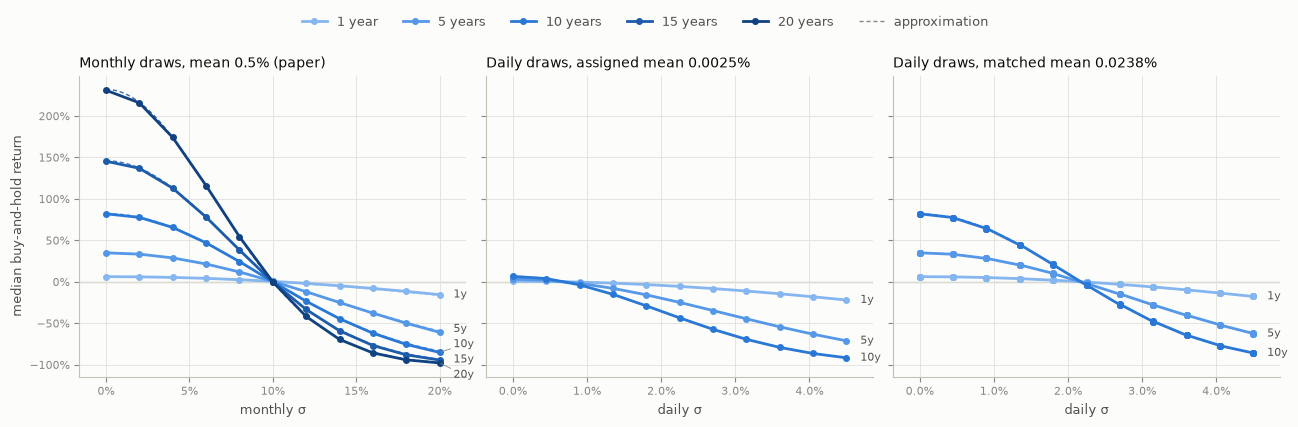

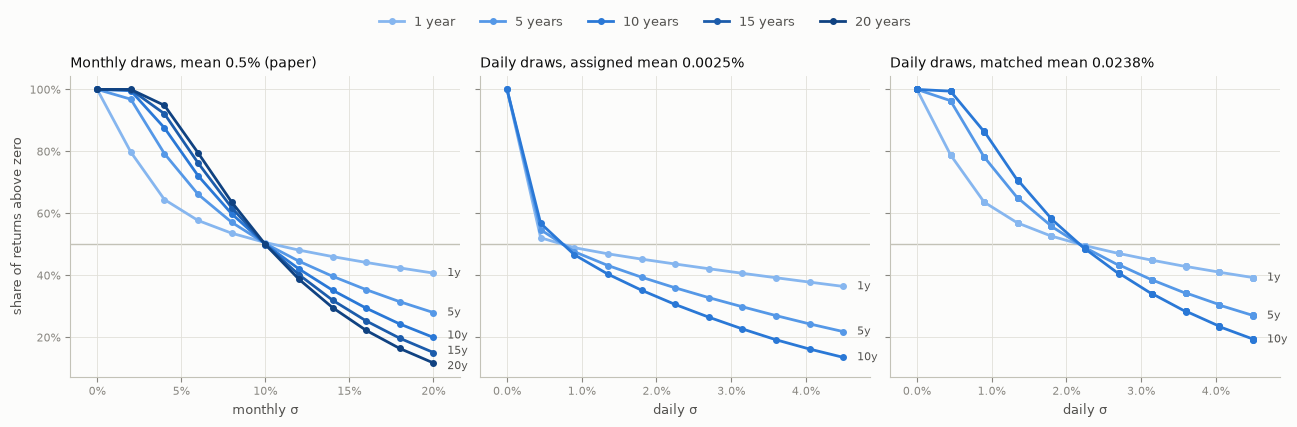

In [19]:
import matplotlib.pyplot as plt
from matplotlib.transforms import offset_copy
from matplotlib.ticker import PercentFormatter

INK, INK_2, MUTED, GRID, BASE, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
# Ordinal blue ramp (validated light to dark): one step per horizon, the same step in every panel.
HORIZON_COLORS = {1: "#86b6ef", 5: "#5598e7", 10: "#2a78d6", 15: "#1c5cab", 20: "#104281"}

experiments = [
    ("Monthly draws, mean 0.5% (paper)", combined, MONTHLY_MU, 12, "monthly σ"),
    ("Daily draws, assigned mean 0.0025%", daily[daily["seed"] == 0], ASSIGNED_MU, 252, "daily σ"),
    ("Daily draws, matched mean 0.0238%", matched, MATCHED_MU, 252, "daily σ"),
]


def spread(values, gap, iterations=500):
    # Push sorted label positions apart until neighbours are at least `gap` apart, keeping their centre.
    order = np.argsort(values)
    pos = np.asarray(values, dtype=float)[order]
    for _ in range(iterations):
        overlaps = gap - np.diff(pos)
        if (overlaps <= 1e-12).all():
            break
        for i in np.flatnonzero(overlaps > 1e-12):
            pos[i] -= overlaps[i] / 2
            pos[i + 1] += overlaps[i] / 2
    out = np.empty_like(pos)
    out[order] = pos
    return out


def label_line_ends(fig, ax, ends, gap_points=11):
    # Direct-label each line at its last point; labels that would collide are spread apart with a leader.
    height = ax.get_position().height * fig.get_figheight() * 72
    low, high = ax.get_ylim()
    gap = gap_points * (high - low) / height
    placed = spread([y for _, y, _ in ends], gap)
    text_at = offset_copy(ax.transData, fig=fig, x=10, units="points")
    for (x, y, text), label_y in zip(ends, placed):
        leader = dict(arrowstyle="-", color=MUTED, linewidth=0.6, shrinkA=0, shrinkB=1) \
            if abs(label_y - y) > gap / 4 else None
        ax.annotate(text, xy=(x, y), xytext=(x, label_y), textcoords=text_at, va="center",
                    fontsize=8, color=INK_2, arrowprops=leader)


def horizon_figure(stat, ylabel, reference, approximation, path):
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True, facecolor=SURFACE)
    line_ends = []
    for ax, (title, frame, mu, per_year, xlabel) in zip(axes, experiments):
        ax.set_facecolor(SURFACE)
        ax.axhline(reference, color=BASE, linewidth=1, zorder=1)
        ends = []
        for years, group in frame.groupby("horizon_years"):
            group = group.sort_values("sigma")
            color = HORIZON_COLORS[int(round(years))]
            ax.plot(group["sigma"], group[stat], color=color, linewidth=2, marker="o", markersize=4,
                    zorder=3, label=f"{years:.0f} year" + ("" if round(years) == 1 else "s"))
            if approximation:
                grid = np.linspace(0, group["sigma"].max(), 100)
                periods = years * per_year
                ax.plot(grid, np.exp(periods * (mu - grid**2 / 2)) - 1, color=color, linewidth=1,
                        linestyle=(0, (3, 2)), alpha=0.8, zorder=2)
            last = group.iloc[-1]
            ends.append((last["sigma"], last[stat], f"{years:.0f}y"))
        line_ends.append((ax, ends))
        ax.set_title(title, fontsize=10, color=INK, loc="left")
        ax.set_xlabel(xlabel, color=INK_2, fontsize=9)
        ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=1 if per_year == 252 else 0))
        ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
        ax.grid(True, color=GRID, linewidth=0.6)
        ax.tick_params(colors=MUTED, labelsize=8)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
        for side in ("left", "bottom"):
            ax.spines[side].set_color(BASE)
        ax.margins(x=0.08)
    axes[0].set_ylabel(ylabel, color=INK_2, fontsize=9)
    handles, labels = axes[0].get_legend_handles_labels()
    if approximation:
        handles.append(plt.Line2D([], [], color=MUTED, linewidth=1, linestyle=(0, (3, 2))))
        labels.append("approximation")
    fig.legend(handles, labels, loc="upper center", ncol=len(labels), frameon=False, fontsize=9,
               bbox_to_anchor=(0.5, 1.02), labelcolor=INK_2)
    fig.tight_layout(rect=(0, 0, 1, 0.93))
    for ax, ends in line_ends:
        label_line_ends(fig, ax, ends)
    fig.savefig(path, dpi=150, facecolor=SURFACE)
    plt.show()


horizon_figure("median", "median buy-and-hold return", 0.0, True, OUTPUT / "fig_median_vs_sigma.png")
horizon_figure("pct_positive", "share of returns above zero", 0.5, False, OUTPUT / "fig_pct_positive_vs_sigma.png")

In [20]:
monthly0 = seed0(combined)
threshold = np.sqrt(2 * ASSIGNED_MU)

by_sigma = monthly0.pivot(index="sigma", columns="horizon_years", values="median")
rising = [s for s in by_sigma.index if s > 0 and by_sigma.loc[s].is_monotonic_increasing]
falling = [s for s in by_sigma.index if s > 0 and by_sigma.loc[s].is_monotonic_decreasing]
at20 = monthly0[monthly0["horizon_years"] == 20].set_index("sigma")
boundary20 = extension[(extension["sigma"] == 0.1) & (extension["horizon_years"] == 20)]
mean20 = (1 + MONTHLY_MU) ** 240 - 1
peaks = extension.loc[extension.groupby(["seed", "horizon_years"])["p99"].idxmax()]
peak_range = peaks.groupby("horizon_years")["sigma"].agg(["min", "max"])
peak_text = " and ".join(f"{r['min']:.0%} for {years_text(h)}" if r["min"] == r["max"]
                        else f"{r['min']:.0%}–{r['max']:.0%} for {years_text(h)}" for h, r in peak_range.iterrows())
peak_agree = bool((peak_range["min"] == peak_range["max"]).all())
p99_by_horizon_20 = monthly0[monthly0["sigma"] == 0.2].sort_values("horizon_years")["p99"]
p99_grid = monthly0[monthly0["sigma"] > 0].pivot(index="sigma", columns="horizon_years", values="p99")
p99_grows = all(p99_grid.loc[s].is_monotonic_increasing for s in p99_grid.index)
ext_warn = extension_skew[extension_skew["sigma"] > 0]
n_warned = int((ext_warn["warning"] == "warning triggered").sum())
top_exact = ext_warn.loc[ext_warn["exact_skew"].idxmax()]


def pcts(sigmas, digits=0):
    return ", ".join(f"{s:.{digits}%}" for s in sigmas)


display(Markdown(rf'''
**The assigned daily mean.** With a mean of 0.0025% a day, the approximate typical log growth $\mu - \sigma^2/2$ turns negative once $\sigma$ exceeds about $\sqrt{{2\mu}}$ = {threshold:.2%} a day. This is a small-return approximation, not an exact property of the model: under the literal normal model a gross return can be negative, so $E[\log(1+r)]$ is not defined, although the approximation is good intuition where gross returns are positive with very high probability. The simulated median is negative for {crossing_text(median_cross)}, and the share of positive returns is below one half for {crossing_text(positive_cross)}, consistent with the approximation on this grid. In the paper's monthly setup the median stays positive up to about 10% monthly volatility. The difference comes from the mean, not from daily compounding: the assigned mean is about a tenth of the paper's 0.5% a month, so volatility drag pulls the typical outcome below zero at far lower volatility.

**Daily versus monthly compounding.** Sampling frequency is not what drives Table 1. At the matched mean the daily table is close to the paper's, and the gap splits into three parts (Step 3). {"The volatility-grid effect lowers the median in every cell and every seed: the daily grid implies slightly more volatility than the paper's columns. " if grid_consistent else ""}In five-seed means (percentage points), the daily/monthly model effect on the median is, at 1 year: {range_sign("model", "median", 1.0)}; at 10 years: {range_sign("model", "median", 10.0)}. On the 10-year 99th percentile it is {range_sign("model", "p99", 10.0)}. These are Monte Carlo estimates of a model difference. Agreement across five seeds indicates sign consistency in these runs, not an established population sign or a calibrated significance test. The paper replication residual is unexplained and consistent with Monte Carlo variability and rounding; undocumented implementation differences cannot be ruled out. Whatever the sampling frequency, at a fixed mean the median and the share of positive returns fall as volatility rises.

**What 15 and 20 years add.** The population expected 20-year return is {mean20:.1%} at every volatility; the simulated means differ from it, sharply so at high volatility (Step 4). Seed 0's median rises with horizon at $\sigma$ = {pcts(rising)}, where the approximate typical log growth is positive, and falls with horizon at $\sigma$ = {pcts(falling)}, where it is negative. At $\sigma$ = 10% the approximation puts typical log growth near zero, and the simulation does not resolve the sign: across the five seeds the 20-year median ranges from {boundary20["median"].min():.3%} to {boundary20["median"].max():.3%}, and the share of positive outcomes from {boundary20["pct_positive"].min():.3%} to {boundary20["pct_positive"].max():.3%}. At $\sigma$ = 20%, the 20-year median is {at20.loc[0.2, "median"]:.1%} and only {at20.loc[0.2, "pct_positive"]:.1%} of outcomes are positive, yet the population expected return is still {mean20:.1%}, so the expectation rests on a small minority of very large outcomes. The 99th percentile {"grows with horizon at every volatility" if p99_grows else "mostly grows with horizon"} (at 20%: {", ".join(f"{v:.0%}" for v in p99_by_horizon_20)} from 1 to 20 years, seed 0). Across volatilities, on this grid, it peaks at $\sigma$ = {peak_text}{", in all five seeds" if peak_agree else ""}, and falls beyond that while the population expected return stays the same. That is a feature of the specified grid, not an optimum over continuous volatility.

**Skewness.** At 15 and 20 years the population skewness reaches {top_exact["exact_skew"]:,.0f} ({years_text(top_exact["horizon_years"])}, $\sigma$ = {top_exact["sigma"]:.0%}), against a sample-skewness bound of about {top_exact["skew_bound"]:.0f}; {n_warned} of {len(ext_warn)} positive-volatility cells trigger a warning. At these horizons the simulated skewness says only that the distribution is very right-skewed; the population values are the reliable measure.

**Compared with Table 1.** The replication reproduces the paper's pattern at every horizon: the same population expected return at every volatility, a median and a share of positive returns that fall as volatility rises, and a right tail that stretches with horizon. The daily and longer-horizon extensions strengthen that pattern rather than change it.
'''))


**The assigned daily mean.** With a mean of 0.0025% a day, the approximate typical log growth $\mu - \sigma^2/2$ turns negative once $\sigma$ exceeds about $\sqrt{2\mu}$ = 0.71% a day. This is a small-return approximation, not an exact property of the model: under the literal normal model a gross return can be negative, so $E[\log(1+r)]$ is not defined, although the approximation is good intuition where gross returns are positive with very high probability. The simulated median is negative for every daily $\sigma$ from 0.90% up, at all three horizons, and the share of positive returns is below one half for every daily $\sigma$ from 0.90% up, at all three horizons, consistent with the approximation on this grid. In the paper's monthly setup the median stays positive up to about 10% monthly volatility. The difference comes from the mean, not from daily compounding: the assigned mean is about a tenth of the paper's 0.5% a month, so volatility drag pulls the typical outcome below zero at far lower volatility.

**Daily versus monthly compounding.** Sampling frequency is not what drives Table 1. At the matched mean the daily table is close to the paper's, and the gap splits into three parts (Step 3). The volatility-grid effect lowers the median in every cell and every seed: the daily grid implies slightly more volatility than the paper's columns. In five-seed means (percentage points), the daily/monthly model effect on the median is, at 1 year: −0.56 to −0.02, negative in every cell and all five seeds; at 10 years: −0.19 to +2.80, positive in all five seeds in 5 of 10 cells. On the 10-year 99th percentile it is −64.49 to +1.22, without a sign shared by all five seeds in any cell. These are Monte Carlo estimates of a model difference. Agreement across five seeds indicates sign consistency in these runs, not an established population sign or a calibrated significance test. The paper replication residual is unexplained and consistent with Monte Carlo variability and rounding; undocumented implementation differences cannot be ruled out. Whatever the sampling frequency, at a fixed mean the median and the share of positive returns fall as volatility rises.

**What 15 and 20 years add.** The population expected 20-year return is 231.0% at every volatility; the simulated means differ from it, sharply so at high volatility (Step 4). Seed 0's median rises with horizon at $\sigma$ = 2%, 4%, 6%, 8%, where the approximate typical log growth is positive, and falls with horizon at $\sigma$ = 12%, 14%, 16%, 18%, 20%, where it is negative. At $\sigma$ = 10% the approximation puts typical log growth near zero, and the simulation does not resolve the sign: across the five seeds the 20-year median ranges from -0.531% to 0.123%, and the share of positive outcomes from 49.858% to 50.032%. At $\sigma$ = 20%, the 20-year median is -97.9% and only 11.7% of outcomes are positive, yet the population expected return is still 231.0%, so the expectation rests on a small minority of very large outcomes. The 99th percentile grows with horizon at every volatility (at 20%: 305%, 1423%, 2773%, 3398%, 3613% from 1 to 20 years, seed 0). Across volatilities, on this grid, it peaks at $\sigma$ = 18% for 15 years and 16% for 20 years, in all five seeds, and falls beyond that while the population expected return stays the same. That is a feature of the specified grid, not an optimum over continuous volatility.

**Skewness.** At 15 and 20 years the population skewness reaches 425,770 (20 years, $\sigma$ = 20%), against a sample-skewness bound of about 500; 12 of 20 positive-volatility cells trigger a warning. At these horizons the simulated skewness says only that the distribution is very right-skewed; the population values are the reliable measure.

**Compared with Table 1.** The replication reproduces the paper's pattern at every horizon: the same population expected return at every volatility, a median and a share of positive returns that fall as volatility rises, and a right tail that stretches with horizon. The daily and longer-horizon extensions strengthen that pattern rather than change it.


### Step 6: Can this explain the low-volatility puzzle?

The low-volatility puzzle is the finding that stocks with low volatility or low beta have earned higher risk-adjusted returns than stocks with high volatility or beta, and in many samples no lower raw returns. The evidence uses related but different measures: Ang, Hodrick, Xing and Zhang (2006) sort stocks on idiosyncratic volatility relative to the Fama–French model; Baker, Bradley and Wurgler (2011) study total volatility and beta; Frazzini and Pedersen (2014) study beta and funding constraints. The simulation has none of that structure. Its $\sigma$ is the total volatility of a single asset, with no market factor, no beta and no correlation between assets. The numbers below come from Steps 2 and 4 (seed 0, monthly mean 0.5%).

In [21]:
low, high = 0.04, 0.16
cells = monthly0.set_index(["horizon_years", "sigma"])
rows = []
for years in (10, 20):
    for s in (low, high):
        rows.append({"horizon (years)": years, "monthly sigma": s,
                     "population expected return": (1 + MONTHLY_MU) ** (12 * years) - 1,
                     "median": cells.loc[(years, s), "median"],
                     "share positive": cells.loc[(years, s), "pct_positive"],
                     "99th percentile": cells.loc[(years, s), "p99"]})
illustration = pd.DataFrame(rows)
display(illustration.style.hide(axis="index").format({
    "monthly sigma": "{:.0%}", "population expected return": "{:.1%}", "median": "{:.1%}",
    "share positive": "{:.1%}", "99th percentile": "{:.0%}"}))
low10, high10 = illustration.iloc[0], illustration.iloc[1]
display(Markdown(rf'''
Both volatilities have the same monthly expected return, so the same population expected 10-year return ({low10["population expected return"]:.1%}). Yet the median 10-year return is {low10["median"]:.1%} at {low:.0%} monthly volatility and {high10["median"]:.1%} at {high:.0%}, and the share of positive outcomes falls from {low10["share positive"]:.1%} to {high10["share positive"]:.1%}.
'''))

horizon (years),monthly sigma,population expected return,median,share positive,99th percentile
10,4%,81.9%,65.5%,87.6%,359%
10,16%,81.9%,-62.0%,29.4%,2315%
20,4%,231.0%,174.0%,94.9%,1046%
20,16%,231.0%,-85.8%,22.2%,4887%



Both volatilities have the same monthly expected return, so the same population expected 10-year return (81.9%). Yet the median 10-year return is 65.5% at 4% monthly volatility and -62.0% at 16%, and the share of positive outcomes falls from 87.6% to 29.4%.


**What compounding does explain.** At the same arithmetic expected return, a higher-volatility asset has a lower median buy-and-hold return and a lower chance of ending above zero, and the gap widens with horizon (table above). Volatility drag, roughly $\sigma^2/2$ per period in typical log growth, pulls the median down, while a small minority of very large outcomes keeps the expected return unchanged. So when the puzzle is stated in terms of typical long-horizon outcomes of individual high-volatility assets, such as their median buy-and-hold return or how often they end with a gain, compounding produces a related difference without any difference in expected returns. The notebook compares marginal distributions only: it does not estimate how often a high-volatility asset ends behind a low-volatility one or behind a market benchmark, which would need an explicitly specified joint experiment. Likewise, cumulative-wealth charts of low- versus high-volatility portfolios measure realized compounded performance; volatility drag enters them too, so differences in such charts cannot by themselves identify differences in arithmetic expected returns.

**What it does not explain.** The anomaly in the literature is measured with average (arithmetic) returns and alphas of portfolios, usually rebalanced monthly. In this simulation arithmetic expected returns are equal by construction, so it cannot produce the lower average returns or negative alphas of high-volatility stocks, and a lower median is not a lower expected return. Having no factor structure, it also cannot speak to idiosyncratic volatility or beta as such. In rebalanced portfolios, diversification removes much of the idiosyncratic variance and with it much of the drag, although drag from common-factor volatility remains.

**Possible mechanisms, not results of the simulation.** Two explanations from the literature work through different channels. *Lottery preferences:* investors who like positively skewed payoffs may bid up high-volatility, lottery-like stocks and accept lower expected returns (Barberis and Huang 2008; Bali, Cakici and Whitelaw 2011). The simulation shows that compounding makes long-horizon returns strongly right-skewed (Panel A), the kind of skewness this channel involves, but not that investors price it. *Leverage constraints:* investors who cannot borrow tilt toward high-beta assets to raise expected returns, flattening the security market line (Frazzini and Pedersen 2014). That channel works through beta and funding constraints and does not depend on the compounded skewness shown here. The simulation cannot tell whether either mechanism operates.

**Conclusion.** Compounding explains a related difference in typical long-horizon outcomes: at equal expected returns, higher volatility means a lower median buy-and-hold return and a lower chance of a gain. This experiment does not explain the empirical arithmetic-return or risk-adjusted-return anomaly itself.

**References.** Ang, A., R. Hodrick, Y. Xing and X. Zhang (2006), "The Cross-Section of Volatility and Expected Returns," *Journal of Finance* ([NBER working paper](https://www.nber.org/papers/w10852)). Baker, M., B. Bradley and J. Wurgler (2011), "Benchmarks as Limits to Arbitrage: Understanding the Low-Volatility Anomaly," *Financial Analysts Journal*. Bali, T., N. Cakici and R. Whitelaw (2011), "Maxing Out: Stocks as Lotteries and the Cross-Section of Expected Returns," *Journal of Financial Economics*. Barberis, N. and M. Huang (2008), "Stocks as Lotteries: The Implications of Probability Weighting for Security Prices," *American Economic Review*. Frazzini, A. and L. Pedersen (2014), "Betting Against Beta," *Journal of Financial Economics* ([NBER working paper](https://www.nber.org/papers/w16601)).